# Setup and Cached Imports

In [1]:
import numpy as np
from scipy.misc import face
from scipy.ndimage import zoom
from scipy.special import logsumexp
import torch

import deepgaze_pytorch
from deepgaze_pytorch import MSDBDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = deepgaze_pytorch.DeepGazeMSDB(pretrained=True).to(DEVICE)

image = face()

# load precomputed centerbias log density (from MIT1003) over a 1024x1024 image
# you can download the centerbias from https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy
# alternatively, you can use a uniform centerbias via `centerbias_template = np.zeros((1024, 1024))`.
centerbias_template = np.load('../centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)

def predict_log_density(image, centerbias):
    print(f"Predicting log density for image of shape {image.shape}")
    image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(DEVICE)
    centerbias_tensor = torch.tensor([centerbias]).to(DEVICE)

    # For a new/unknown dataset, use averaged parameters for generalization:
    log_density_prediction = model(image_tensor, centerbias_tensor, pixel_per_dva=35.0, dataset=None)
    return log_density_prediction

Using cache found in /u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/u/b/chengn30/.cache/torch/hub/facebookresearch_dinov2_6a62615/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/tmp/ipykernel_137509/2258322700.py:14: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  image = face()


In [2]:
import os

import matplotlib.pyplot as plt
from pysaliency.plotting import visualize_distribution

INPUT_PATH = 'inputs'
OUTPUT_PATH = 'outputs'

def visualize_prediction(image, log_density_prediction, log_path, heatmap_path):
    fig, ax = plt.subplots()
    ax.imshow(image)
    
    fig, ax = plt.subplots()
    ax.set_axis_off()
    ax.matshow(log_density_prediction.detach().cpu().numpy()[0])  # first image in batch
    plt.savefig(log_path, bbox_inches='tight', pad_inches=0)
    
    # f, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    # axs[0].imshow(image)
    # axs[0].set_axis_off()
    # axs[1].matshow(log_density_prediction.detach().cpu().numpy()[0])  # first image in batch
    # axs[1].set_axis_off()
    # visualize_distribution(log_density_prediction.detach().cpu().numpy()[0], ax=axs[2])
    # axs[2].set_axis_off()
    fig, ax = plt.subplots()
    ax.set_axis_off()
    visualize_distribution(log_density_prediction.detach().cpu().numpy()[0], ax=ax)
    plt.savefig(heatmap_path, bbox_inches='tight', pad_inches=0)

/u/b/chengn30/DeepGaze/venv/lib64/python3.9/site-packages/pysaliency/external_models/matlab_models.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


# Processing Loop

Skipping image 0000 because output already exists.
Skipping image 0001 because output already exists.
Skipping image 0002 because output already exists.
Skipping image 0003 because output already exists.
Skipping image 0004 because output already exists.
Skipping image 0005 because output already exists.
Skipping image 0006 because output already exists.
Skipping image 0007 because output already exists.
Skipping image 0008 because output already exists.
Skipping image 0009 because output already exists.
Skipping image 0010 because output already exists.
Skipping image 0011 because output already exists.
Skipping image 0012 because output already exists.
Skipping image 0013 because output already exists.
Skipping image 0014 because output already exists.
Skipping image 0015 because output already exists.
(768, 1024, 3)
Predicting log density for image of shape (768, 1024, 3)
(768, 1024, 3)
Predicting log density for image of shape (768, 1024, 3)
(768, 1024, 3)
Predicting log density fo

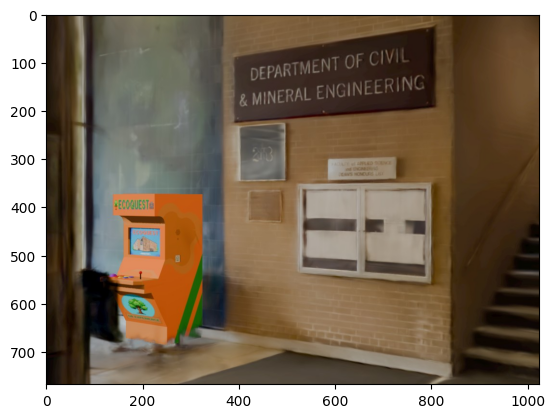

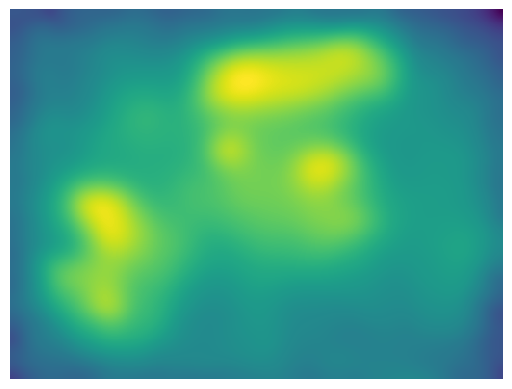

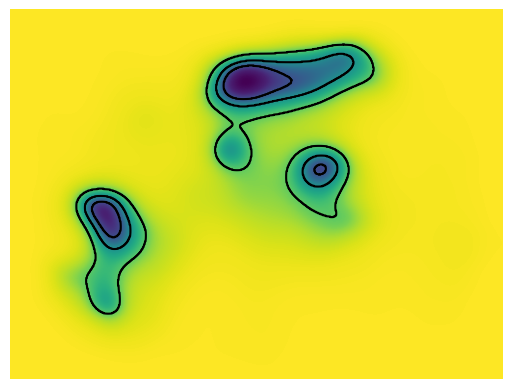

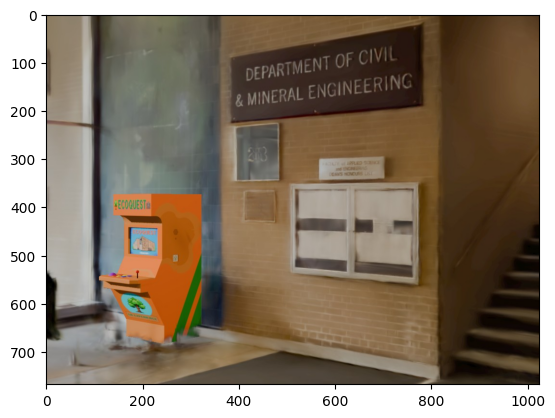

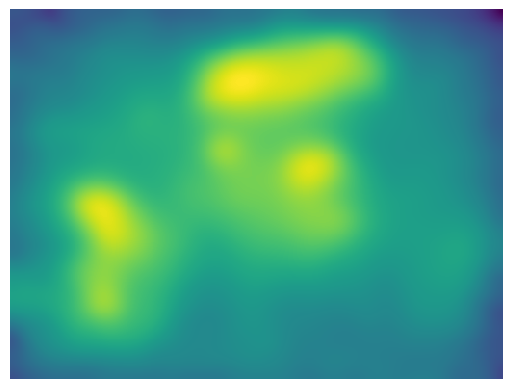

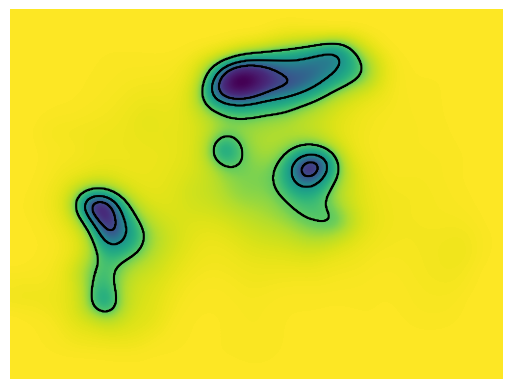

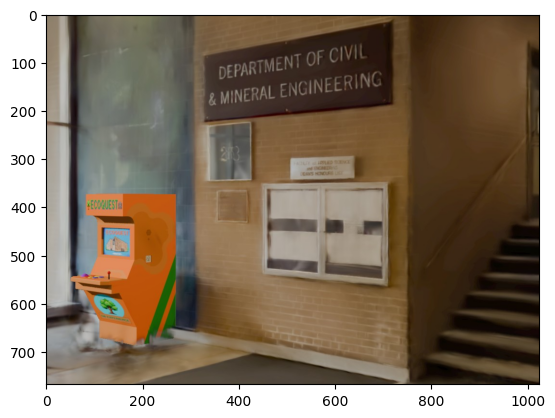

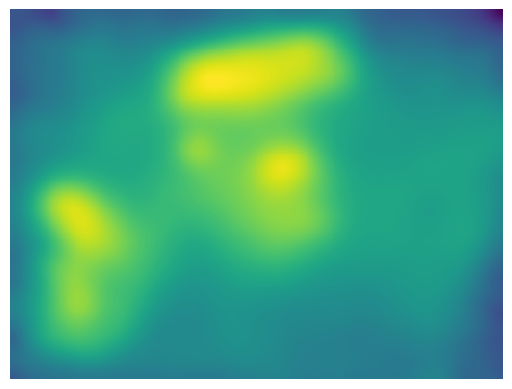

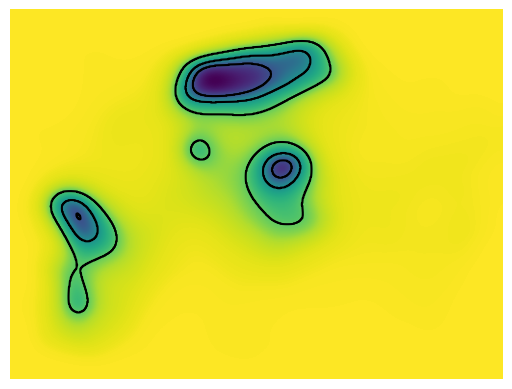

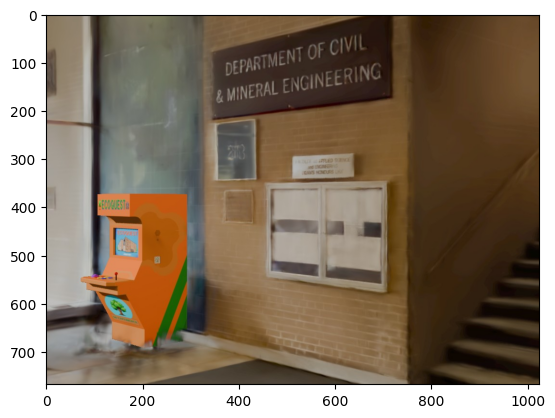

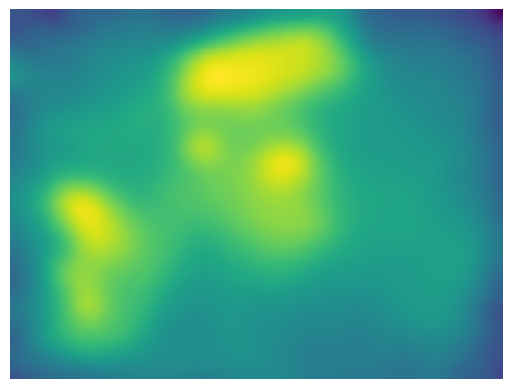

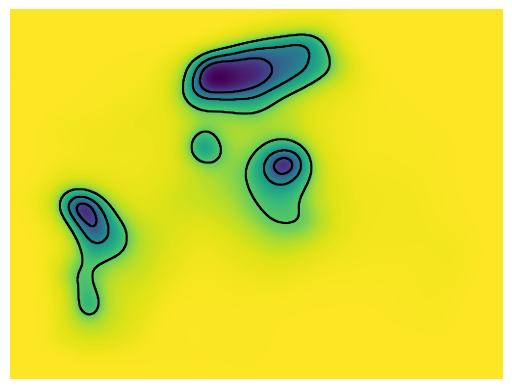

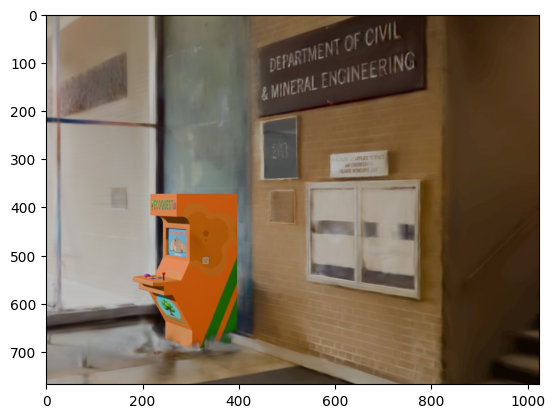

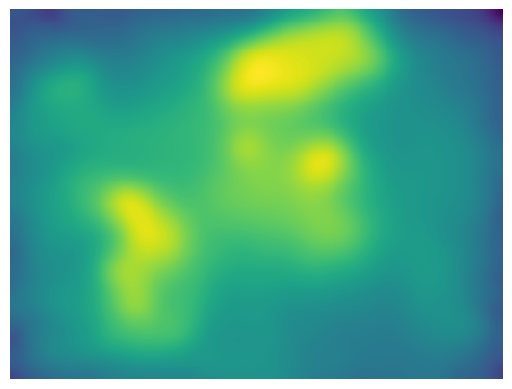

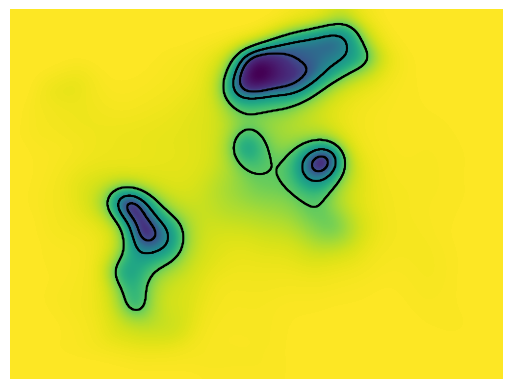

In [5]:
from PIL import Image
import numpy as np
import os
from pathlib import Path
from IPython.display import clear_output

INPUT_PATH = 'inputs'
input_batch_size = len(list(Path(INPUT_PATH).iterdir())) // 2

OUTPUT_PATH = 'outputs'

overwrite_existing = False

for i in range(input_batch_size):
    prob_path = os.path.join(OUTPUT_PATH, f'probabilities/prob_{i:04d}.npy')
    if (not overwrite_existing) and os.path.exists(prob_path):
        print(f"Skipping image {i:04d} because output already exists.")
        continue
    
    composite_path = os.path.join(INPUT_PATH, f'render{i:04d}_composite.jpg')
    color_path = os.path.join(INPUT_PATH, f'render{i:04d}_color.jpg')

    if os.path.exists(composite_path):
        image = np.array(Image.open(composite_path))
        
        print(image.shape)
        
        # Make sure image is RGB (not RGBA)
        if image.shape[2] == 4:
            image = image[:, :, :3]
        
        # Predict with DeepGaze MSDB
        log_density_prediction = predict_log_density(image, centerbias)
        
        # Save probability density
        log_density_np = log_density_prediction.detach().cpu().numpy()[0]
        prob_density = np.exp(log_density_np)
        
        prob_path = os.path.join(OUTPUT_PATH, f'probabilities/prob_{i:04d}.npy')
        os.makedirs(os.path.dirname(prob_path), exist_ok=True)
        np.save(prob_path, prob_density)
        
        # Save heatmaps
        log_path = os.path.join(OUTPUT_PATH, f'log-density/log_{i:04d}.png')
        heatmap_path = os.path.join(OUTPUT_PATH, f'heatmaps/heat_{i:04d}.png')
        visualize_prediction(image, log_density_prediction, log_path, heatmap_path)
    else:
        print(f"Error: The file '{composite_path}' was not found.")

# Arcade Visibility Integral

This section estimates where the arcade cabinet is visible by subtracting the color image from the composite image. It then integrates the predicted probability density over those coordinates.

In [6]:
from pathlib import Path
import numpy as np
from PIL import Image
import os
from scipy.ndimage import label as connected_components_label


def arcade_visibility_mask(composite_rgb, color_rgb, diff_threshold=15, min_channel_diffs=1):
    """Estimate object visibility mask from absolute RGB differences."""
    if composite_rgb.shape != color_rgb.shape:
        raise ValueError(
            f"Shape mismatch: composite {composite_rgb.shape} vs color {color_rgb.shape}"
        )

    diff = np.abs(composite_rgb.astype(np.int16) - color_rgb.astype(np.int16))
    return (diff > diff_threshold).sum(axis=2) >= min_channel_diffs


def largest_connected_component(mask):
    """Keep only the largest 8-connected component in a binary mask."""
    labeled_mask, num_components = connected_components_label(mask, structure=np.ones((3, 3), dtype=int))

    if num_components == 0:
        return mask

    component_sizes = np.bincount(labeled_mask.ravel())
    component_sizes[0] = 0
    largest_component = component_sizes.argmax()
    return labeled_mask == largest_component


def component_bounding_box(mask):
    """Return bounding box (row_min, row_max, col_min, col_max) for a binary mask."""
    rows, cols = np.where(mask)
    if rows.size == 0:
        return None
    return int(rows.min()), int(rows.max()), int(cols.min()), int(cols.max())


def apply_mask_to_image(image_rgb, mask):
    """Return the input image with everything outside the mask set to black."""
    masked_image = np.zeros_like(image_rgb)
    masked_image[mask] = image_rgb[mask]
    return masked_image


def draw_bounding_box(image_rgb, bbox, color=(0, 0, 255), thickness=3):
    """Draw a rectangular bounding box on an RGB image."""
    row_min, row_max, col_min, col_max = bbox
    h, w = image_rgb.shape[:2]

    r0 = max(0, row_min)
    r1 = min(h - 1, row_max)
    c0 = max(0, col_min)
    c1 = min(w - 1, col_max)

    if r0 > r1 or c0 > c1:
        return image_rgb

    boxed = image_rgb.copy()

    # Top and bottom edges
    boxed[r0:r0 + thickness, c0:c1 + 1] = color
    boxed[max(r1 - thickness + 1, 0):r1 + 1, c0:c1 + 1] = color

    # Left and right edges
    boxed[r0:r1 + 1, c0:c0 + thickness] = color
    boxed[r0:r1 + 1, max(c1 - thickness + 1, 0):c1 + 1] = color

    return boxed


prob_dir = Path(OUTPUT_PATH) / 'probabilities'
prob_files = sorted(prob_dir.glob('prob_*.npy'))

if not prob_files:
    print(f"No probability files found in {prob_dir}")
else:
    masses = []

    for prob_file in prob_files:
        frame_idx = int(prob_file.stem.split('_')[1])

        composite_path = os.path.join(INPUT_PATH, f'render{frame_idx:04d}_composite.jpg')
        color_path = os.path.join(INPUT_PATH, f'render{frame_idx:04d}_color.jpg')

        if not (os.path.exists(composite_path) and os.path.exists(color_path)):
            print(f"Skipping frame {frame_idx:04d}: missing composite or color image")
            continue

        composite = np.array(Image.open(composite_path).convert('RGB'))
        color = np.array(Image.open(color_path).convert('RGB'))
        prob_density = np.load(prob_file)

        if prob_density.shape != composite.shape[:2]:
            print(
                f"Skipping frame {frame_idx:04d}: probability shape {prob_density.shape} "
                f"does not match image shape {composite.shape[:2]}"
            )
            continue

        mask = arcade_visibility_mask(composite, color, diff_threshold=15, min_channel_diffs=1)
        mask = largest_connected_component(mask)

        bbox = component_bounding_box(mask)
        if bbox is None:
            print(f"Skipping frame {frame_idx:04d}: empty mask")
            continue

        row_min, row_max, col_min, col_max = bbox
        visible_mass = float(prob_density[row_min:row_max + 1, col_min:col_max + 1].sum())
        masses.append(visible_mass)

        masked_image = apply_mask_to_image(composite, mask)
        masked_image = draw_bounding_box(masked_image, bbox, color=(0, 0, 255), thickness=3)
        masked_path = Path(OUTPUT_PATH) / 'masked' / f'masked_{frame_idx:04d}.png'
        os.makedirs(masked_path.parent, exist_ok=True)
        Image.fromarray(masked_image).save(masked_path)

    if masses:
        masses = np.array(masses, dtype=float)
        mean_mass = float(masses.mean())

        print('\nSummary')
        print(f"Frames processed: {len(masses)}")
        print(f"Mean visible mass: {mean_mass:.6f}")
        print(f"Median visible mass: {np.median(masses):.6f}")
        print(f"Min/Max visible mass: {masses.min():.6f} / {masses.max():.6f}")

        out_path = Path(OUTPUT_PATH) / 'probabilities' / 'arcade_visible_masses.txt'
        os.makedirs(out_path.parent, exist_ok=True)
        with open(out_path, 'w', encoding='utf-8') as f:
            f.write(f"mean_visible_mass,{mean_mass:.10f}\n")
            f.write("visible_mass\n")
            for mass in masses:
                f.write(f"{mass:.10f}\n")

        print(f"Saved masked images to {Path(OUTPUT_PATH) / 'masked'}")
        print(f"Saved mean + mass list to {out_path}")
    else:
        print("No valid frames to compute masses.")


Summary
Frames processed: 21
Mean visible mass: 0.328588
Median visible mass: 0.273596
Min/Max visible mass: 0.036207 / 0.767717
Saved masked images to outputs/masked
Saved mean + mass list to outputs/probabilities/arcade_visible_masses.txt
